# Lab 2: CNN for Image Classification (PetFinder)

**Name:** Logan Banister

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [24]:
# Your imports here
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt


In [17]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [6]:
# Load train.csv here

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255


y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [9]:
# Write your image-loading function here



In [ ]:
# Build X and y, then split into train/test here



*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [10]:
# Build your CNN model here

model = Sequential()

# 1st CNN layer
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Cnn layer
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten layer
model.add(Flatten())

# Fully connected output layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Compile your model here

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

*Your architecture justification (one paragraph):*




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [23]:
# Train your model here (save the result as `history`)



history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9656 - loss: 0.0959 - val_accuracy: 0.9038 - val_loss: 0.3341
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9675 - loss: 0.0895 - val_accuracy: 0.9078 - val_loss: 0.3428
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9688 - loss: 0.0873 - val_accuracy: 0.9027 - val_loss: 0.3749
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9695 - loss: 0.0841 - val_accuracy: 0.9078 - val_loss: 0.3797
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9721 - loss: 0.0776 - val_accuracy: 0.9027 - val_loss: 0.3750
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.9728 - loss: 0.0760 - val_accuracy: 0.8988 - val_loss: 0.4010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9729 - loss: 0.0745 - val_accuracy: 0.9072 - val_loss: 0.3831
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9760 -

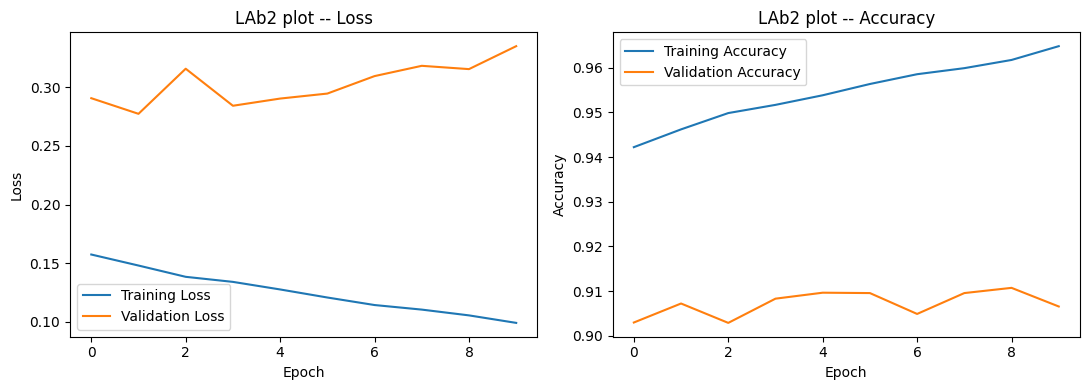

In [21]:
# Plot training vs. validation loss and accuracy here


plot_history(history, "LAb2 plot", show_accuracy=True)

*Your fit diagnosis, with specific evidence from your curve:*




In [22]:
# Evaluate on the test set and report accuracy here

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9020 - loss: 0.3509
Test accuracy: 0.9020000100135803


Our model had a 90% accuracy, but 35% loss. This means it is getting its predicted value right a lot of the time, but it is not very confident in its answers.

---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*




In [30]:
# Build your improved model here

dropout_model = Sequential()

# 1st CNN layer
dropout_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
dropout_model.add(MaxPooling2D(pool_size=(2, 2)))
dropout_model.add(Dropout(0.25))

# 2nd Cnn layer
dropout_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
dropout_model.add(MaxPooling2D(pool_size=(2, 2)))
dropout_model.add(Dropout(0.25))


# Flatten layer
dropout_model.add(Flatten())

# Fully connected output layer
dropout_model.add(Dense(10, activation='softmax'))

dropout_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# Train your improved model here

history = dropout_model.fit(
    x_train, y_train,
    validation_split=0.25,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.7900 - loss: 0.5789 - val_accuracy: 0.8503 - val_loss: 0.4153
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.8564 - loss: 0.3974 - val_accuracy: 0.8737 - val_loss: 0.3482
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8724 - loss: 0.3552 - val_accuracy: 0.8855 - val_loss: 0.3142
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8828 - loss: 0.3256 - val_accuracy: 0.8908 - val_loss: 0.2979
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8871 - loss: 0.3119 - val_accuracy: 0.8953 - val_loss: 0.2824
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8927 - loss: 0.2917 - val_accuracy: 0.8925 - val_loss: 0.2871
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.8964 - loss: 0.2850 - val_accuracy: 0.9013 - val_loss: 0.2676
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8991 -

In [34]:
# Evaluation

test_loss, test_acc = dropout_model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8913 - loss: 0.2908
Test accuracy: 0.8913000226020813


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | | |
| Fit pattern (good/over/under) | | |
| What changed | | |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [ ]:
# Evaluate your improved model and build a confusion matrix here



*Your discussion of the confusion matrix:*




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [ ]:
# Find and display misclassified images here



*Your observations about the misclassified images:*




---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.